In [350]:
import numpy as np
from scipy.interpolate import RegularGridInterpolator
import matplotlib.pyplot as plt

# Implicit method (4.2.5) 

In [351]:
#### ---- Parameters ----

#Numerical method
V_MAX = 201   #number of spatial points in the grid
M = 1000      #number of temporal points in the grid

x_max = 3
x_min = -3


#option
option_type = "call"  #options: "put" or "call"
T = 1   
K = 40


#asset
r = 0.05      #interest rate
delta = 0.02  #dividend yield
sigma = 0.2   #volatily 


### Computation of w:
w: (V_MAX-2, M)
w stores only interior values (excluding x0​ and x_vmax):

In [352]:
#initialization of w

w = np.empty((V_MAX - 2, M))
q_delta = 2 * (r - delta) / (sigma ** 2)

x = np.linspace(x_min, x_max, V_MAX)
x_interior = x[1:-1]  # length V_MAX - 2

if option_type == "call":
    a = -0.5 * (q_delta - 1)
    w[:, 0] = np.maximum(np.exp(x_interior) - 1, 0) * np.exp(a * x_interior)
elif option_type == "put":
    a = -0.5 * (q_delta + 1)
    w[:, 0] = np.maximum(1 - np.exp(x_interior), 0) * np.exp(a * x_interior)
else:
    raise ValueError("option_type must be either 'call' or 'put'")


In [353]:
#A matrix from (4.18)

delta_x = (x_max - x_min) / (V_MAX - 1) 
tau_max = 0.5 * sigma * sigma * T 
delta_tau = tau_max / (M - 1) 

lamb = delta_tau / (delta_x**2)  
print("lambda:", lamb)

A = np.diag((1 + 2 * lamb) * np.ones(V_MAX - 2))
A += np.diag(-lamb * np.ones(V_MAX - 3), k=1)
A += np.diag(-lamb * np.ones(V_MAX - 3), k=-1)

lambda: 0.022244466688911137


In [354]:
print("Shape of A:", A.shape)
print("Shape of w:", w.shape)
print("V_MAX - 2:", V_MAX - 2)
print("M - 1:", M - 1)

Shape of A: (199, 199)
Shape of w: (199, 1000)
V_MAX - 2: 199
M - 1: 999


In [355]:
#compute w(nu+1) from w(nu) using (4.19)
for nu in range(M - 1): 
    w[:, nu + 1] = np.linalg.solve(A, w[:, nu])

### Undo the initial transformation to pass from w(x, tau) (which is the discretized version of y(x, tau)) to v(x, tau) - equations (4.3)

In [356]:
tau = np.linspace(0, tau_max, M)
x = np.linspace(x_min, x_max, V_MAX)
x_interior = x[1:-1] 

q = 2*r/(sigma**2)

v = K * np.exp(
    -0.5 * (q_delta - 1) * x_interior[:, None] 
    - (0.25 * (q_delta - 1)**2 + q) * tau[None, :]
) * w


print(f"v.shape:", v.shape)

v.shape: (199, 1000)


### Pass from x/tau to S/t

In [357]:
#Interpolation
v_interp = RegularGridInterpolator((x_interior, tau), v, bounds_error=False, fill_value=None)

def V(S, t):
    """Compute V(S, t) using interpolated v(x, tau)."""
    x_val = np.log(S / K)
    tau_val = 0.5 * sigma**2 * (T - t)
    return v_interp([x_val, tau_val])


# ---- Example use ----
S_test = 20
t_test = 0.5
print("V(S=50, t=0.5) =", V(S_test, t_test))
print("V(S=50, t=0.8) =", V(25, 0.9))

V(S=50, t=0.5) = [1.59818277e-06]
V(S=50, t=0.8) = [3.84106321e-10]


## Visualization

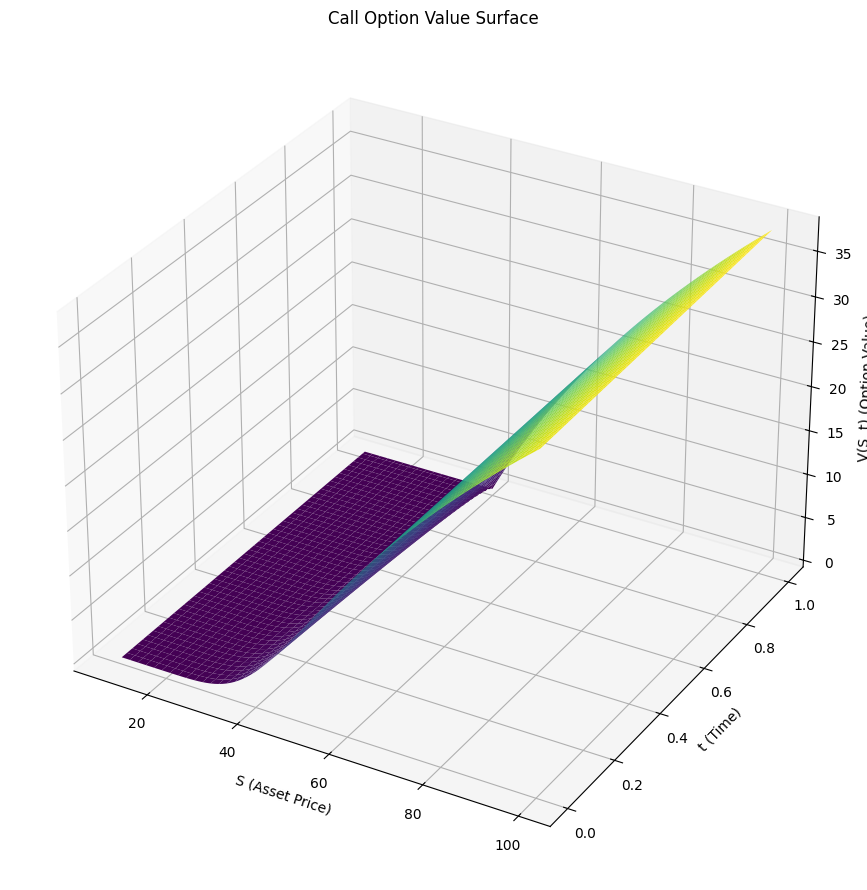

In [358]:
# ---- Grid of values for visualization ----
S_vals = np.linspace(10, 100, 100)
t_vals = np.linspace(0, T, 100)
S_grid, t_grid = np.meshgrid(S_vals, t_vals)

# Compute V(S, t) over the grid
V_func = np.vectorize(V)
V_grid = V_func(S_grid, t_grid)

# ---- Plot the surface ----
fig = plt.figure(figsize=(10, 9))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(S_grid, t_grid, V_grid, cmap='viridis')

ax.set_xlabel('S (Asset Price)')
ax.set_ylabel('t (Time)')
ax.set_zlabel('V(S, t) (Option Value)')
ax.set_title(f"{option_type.capitalize()} Option Value Surface")

plt.tight_layout()
plt.show()


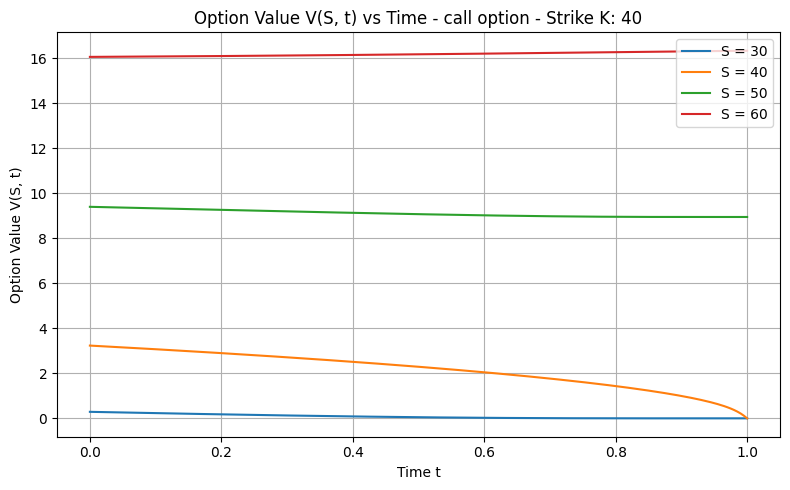

In [359]:
def plot_V_over_time(S_list):
    """
    Plot V(S, t) as a function of time t for each asset price in S_list.
    Assumes V(S, t), K, sigma, T are defined in the environment.
    """
    t_vals = np.linspace(0, T, 200)

    plt.figure(figsize=(8, 5))
    for S in S_list:
        values = [V(S, t) for t in t_vals]
        plt.plot(t_vals, values, label=f"S = {S}")
    
    plt.title(f"Option Value V(S, t) vs Time - {option_type} option - Strike K: {K}")
    plt.xlabel("Time t")
    plt.ylabel("Option Value V(S, t)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_V_over_time([30, 40, 50, 60])